In [1]:
import onnxruntime
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from time import time
import os

In [2]:
def get_color_map_list(num_classes):
    """
    Returns the color map for visualizing the segmentation mask,
    which can support arbitrary number of classes.
    Args:
        num_classes (int): Number of classes.
    Returns:
        (list). The color map.
    """

    num_classes += 1
    color_map = num_classes * [0, 0, 0]
    for i in range(0, num_classes):
        j = 0
        lab = i
        while lab:
            color_map[i * 3] |= (((lab >> 0) & 1) << (7 - j))
            color_map[i * 3 + 1] |= (((lab >> 1) & 1) << (7 - j))
            color_map[i * 3 + 2] |= (((lab >> 2) & 1) << (7 - j))
            j += 1
            lab >>= 3
    color_map = color_map[3:]
    return color_map

In [3]:
color_map = get_color_map_list(256)

In [4]:
def softmax(x):
    max = np.max(x,axis=1,keepdims=True) #returns max of each row and keeps same dims
    e_x = np.exp(x - max) #subtracts each row with its max value
    sum = np.sum(e_x,axis=1,keepdims=True) #returns sum of each row and keeps same dims
    f_x = e_x / sum 
    return f_x

In [5]:
sess_options = onnxruntime.SessionOptions()
sess_options.intra_op_num_threads = 2
# sess_options.execution_mode = onnxruntime.ExecutionMode.ORT_PARALLEL
# sess_options.inter_op_num_threads = 4
# sess_options.graph_optimization_level = onnxruntime.GraphOptimizationLevel.ORT_ENABLE_ALL

In [6]:
print(onnxruntime.get_available_providers())

['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']


In [7]:
onnx_path_demo = r"C:\Users\hp\Desktop\seg_models\mulseg2out.onnx"
# onnx_path_demo = r"E:\code\git\PaddleSeg\yolov3.onnx"
try:
    session = onnxruntime.InferenceSession(onnx_path_demo, providers=['CPUExecutionProvider'])
    # session = onnxruntime.InferenceSession(onnx_path_demo, providers=['CUDAExecutionProvider', 'CPUExecutionProvider'])
except:
    print('error GPU')
    session = onnxruntime.InferenceSession(onnx_path_demo, providers=['CPUExecutionProvider'])
# print(session.get_providers())
inputs_info = session.get_inputs()
for _it in inputs_info:
    print(_it)
print('outputs -------')
outputs_info = session.get_outputs()
for _it in outputs_info:
    print(_it)

NodeArg(name='x', type='tensor(float)', shape=[1, 3, 1024, 1024])
outputs -------
NodeArg(name='bilinear_interp_v2_10.tmp_0', type='tensor(float)', shape=[1, 2, 1024, 1024])
NodeArg(name='bilinear_interp_v2_11.tmp_0', type='tensor(float)', shape=[1, 2, 1024, 1024])


In [8]:
session.get_inputs()[0].name

'x'

In [9]:
def check_one_img(img_path, th = 0.5):
    image_src = cv2.imread(img_path)
    if inputs_info[0].shape[1] == 3:
        # 语义分割
        img_in = cv2.cvtColor(image_src, cv2.COLOR_BGR2RGB)
    else:
        # 单通道语义分割
        # img_in = cv2.cvtColor(image_src, cv2.COLOR_BGR2HSV)
        # img_in = img_in[:,:,2]
        img_in = cv2.cvtColor(image_src, cv2.COLOR_BGR2GRAY)
        img_in = img_in[..., np.newaxis]
        
    img_in = img_in.astype(np.float32)/255.0;img_in = np.transpose(img_in, (2, 0, 1));img_in = np.expand_dims(img_in, axis=0)
    input_name = session.get_inputs()[0].name
    t1 = time()
    outputs = session.run(None, {input_name: img_in})
    print('time costs: ', time()-t1)
    # print(outputs[0].shape)
    out = []
    for i in range(len(outputs)):
        out.append(softmax(outputs[i])) 
    return out

In [10]:
image_path = r'C:\Users\hp\Desktop\test\1\4.jpg'
# image_path = r'C:\Users\hp\Desktop\tc_data\2\rs\rust\37.jpg'
out = check_one_img(image_path)

time costs:  1.6030418872833252


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


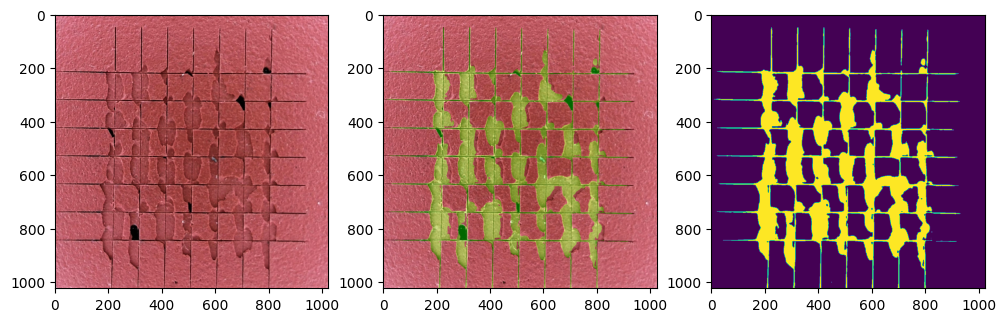

In [12]:
# 多输出
th = 0.5
care = out[0][0][1]>=th
plt.figure(figsize=(12,27))

_src = cv2.imread(image_path); _src = cv2.cvtColor(_src, cv2.COLOR_BGR2RGB)
plt.subplot(1,3,1)
plt.imshow(_src)
_src = _src.astype(np.float32)/255.0
_src[care] = _src[care] + (0,0.4,0)
plt.subplot(1,3,2)
plt.imshow(_src)
binary = np.zeros_like(care, dtype=np.uint8)
binary[care] = 1
plt.subplot(1,3,3)
plt.imshow(binary)

In [11]:
th = 0.5
care = out[0][1]>=th
plt.figure(figsize=(12,27))

_src = cv2.imread(image_path); _src = cv2.cvtColor(_src, cv2.COLOR_BGR2RGB)
plt.subplot(1,3,1)
plt.imshow(_src)
_src = _src.astype(np.float32)/255.0
_src[care] = _src[care] + (0,0.4,0)
plt.subplot(1,3,2)
plt.imshow(_src)
binary = np.zeros_like(care, dtype=np.uint8)
binary[care] = 1
plt.subplot(1,3,3)
plt.imshow(binary)

IndexError: index 1 is out of bounds for axis 0 with size 1

In [ ]:
save_mask_path = r'C:\Users\hp\Desktop'
mask_name = '1.png'
lbl_pil = Image.fromarray(binary)
lbl_pil.putpalette(color_map)
lbl_pil.save(os.path.join(save_mask_path, mask_name))
